In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset (1).csv
Uploaded files:
DataCoSupplyChainDataset (1).csv


In [ ]:
# ============================================
# PHASE A - DATA UNDERSTANDING & VALIDATION
# ============================================

import pandas as pd
import numpy as np

file_path = "DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCOLUMN NAMES:")
print(df.columns.tolist())

print("\nFIRST 5 ROWS:")
display(df.head())

print("\nDATA TYPES:")
display(df.dtypes)

print("\nMISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nDUPLICATE ROWS:", df.duplicated().sum())

print("\nUNIQUE ORDER IDs:", df["Order Id"].nunique())

print("\nUNIQUE CUSTOMER IDs:", df["Customer Id"].nunique())

print("\nDATE RANGE:")
print("Order date:", df["order date (DateOrders)"].min())
print("to:", df["order date (DateOrders)"].max())

DATASET LOADED SUCCESSFULLY
Rows: 180519
Columns: 53

COLUMN NAMES:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Produc

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



DATA TYPES:


,0
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object



MISSING VALUES:


,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3



DUPLICATE ROWS: 0

UNIQUE ORDER IDs: 65752

UNIQUE CUSTOMER IDs: 20652

DATE RANGE:
Order date: 1/1/2015 0:00
to: 9/9/2017 9:50


In [ ]:
# ============================================
# PHASE A - DATA UNDERSTANDING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("Unique orders:", df["Order Id"].nunique())
print("Unique customers:", df["Customer Id"].nunique())

print("\nDate range:")
print(df["order date (DateOrders)"].min(), "→",
      df["order date (DateOrders)"].max())

Dataset shape: (180519, 53)

Columns:
01. Type
02. Days for shipping (real)
03. Days for shipment (scheduled)
04. Benefit per order
05. Sales per customer
06. Delivery Status
07. Late_delivery_risk
08. Category Id
09. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Prod

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Data types:


,0
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object



Missing values:


,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3



Duplicate rows: 0
Unique orders: 65752
Unique customers: 20652

Date range:
1/1/2015 0:00 → 9/9/2017 9:50


In [ ]:
# ============================================
# PHASE A - CLEANING
# ============================================

clean_df = df.copy()

# Convert dates
clean_df["order date (DateOrders)"] = pd.to_datetime(
    clean_df["order date (DateOrders)"],
    errors="coerce"
)

clean_df["shipping date (DateOrders)"] = pd.to_datetime(
    clean_df["shipping date (DateOrders)"],
    errors="coerce"
)

# Standardize column text fields
text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].astype(str).str.strip()

# Remove exact duplicate rows
before = len(clean_df)
clean_df = clean_df.drop_duplicates()
after = len(clean_df)

print("Exact duplicate rows removed:", before - after)

# Basic numeric sanity checks
numeric_cols = clean_df.select_dtypes(include=np.number).columns

negative_counts = (
    clean_df[numeric_cols].lt(0).sum()
    .sort_values(ascending=False)
)

print("\nNegative-value counts:")
display(negative_counts[negative_counts > 0])

print("\nCleaned shape:", clean_df.shape)

Exact duplicate rows removed: 0

Negative-value counts:


,0
Longitude,180414
Benefit per order,33784
Order Item Profit Ratio,33784
Order Profit Per Order,33784
Latitude,9



Cleaned shape: (180519, 53)


In [ ]:
# ============================================
# PHASE A - FEATURE PREPARATION
# ============================================

clean_df["Order Year"] = clean_df["order date (DateOrders)"].dt.year
clean_df["Order Month"] = clean_df["order date (DateOrders)"].dt.month
clean_df["Order Month Name"] = clean_df["order date (DateOrders)"].dt.month_name()
clean_df["Order Quarter"] = clean_df["order date (DateOrders)"].dt.quarter

# Delivery target
clean_df["Late Delivery"] = (
    clean_df["Late_delivery_risk"].astype(int)
)

# Useful business measures
clean_df["Delivery Delay Days"] = (
    clean_df["Days for shipping (real)"]
    - clean_df["Days for shipment (scheduled)"]
)

clean_df["On Time"] = (
    clean_df["Delivery Delay Days"] <= 0
).astype(int)

print("Feature engineering completed ✅")
display(
    clean_df[
        [
            "Order Id",
            "Order Year",
            "Order Month",
            "Days for shipping (real)",
            "Days for shipment (scheduled)",
            "Delivery Delay Days",
            "Late Delivery"
        ]
    ].head()
)

Feature engineering completed ✅


,Order Id,Order Year,Order Month,Days for shipping (real),Days for shipment (scheduled),Delivery Delay Days,Late Delivery
0,77202,2018,1,3,4,-1,0
1,75939,2018,1,5,4,1,1
2,75938,2018,1,4,4,0,0
3,75937,2018,1,3,4,-1,0
4,75936,2018,1,2,4,-2,0


In [ ]:
# ============================================
# PHASE B - SQL DATABASE
# ============================================

import sqlite3

conn = sqlite3.connect("supply_chain.db")

clean_df.to_sql(
    "supply_chain",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created ✅")

SQLite database created ✅


In [ ]:
# ============================================
# PHASE B - SQL BUSINESS ANALYSIS
# ============================================

queries = {

    "sales_orders_units": """
    SELECT
        ROUND(SUM(Sales), 2) AS Total_Sales,
        COUNT(DISTINCT "Order Id") AS Total_Orders,
        SUM("Order Item Quantity") AS Total_Units
    FROM supply_chain;
    """,

    "top_categories": """
    SELECT
        "Category Name",
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM supply_chain
    GROUP BY "Category Name"
    ORDER BY Total_Sales DESC
    LIMIT 10;
    """,

    "regional_revenue": """
    SELECT
        "Order Region",
        ROUND(SUM(Sales), 2) AS Revenue
    FROM supply_chain
    GROUP BY "Order Region"
    ORDER BY Revenue DESC;
    """,

    "shipping_modes": """
    SELECT
        "Shipping Mode",
        COUNT(*) AS Shipments,
        ROUND(AVG("Days for shipping (real)"), 2) AS Avg_Delivery_Days
    FROM supply_chain
    GROUP BY "Shipping Mode"
    ORDER BY Shipments DESC;
    """,

    "late_delivery_rate": """
    SELECT
        ROUND(
            100.0 * AVG("Late Delivery"),
            2
        ) AS Late_Delivery_Rate
    FROM supply_chain;
    """
}

for name, query in queries.items():
    print(f"\n--- {name.upper()} ---")
    display(pd.read_sql_query(query, conn))


--- SALES_ORDERS_UNITS ---


,Total_Sales,Total_Orders,Total_Units
0,36784735.01,65752,384079



--- TOP_CATEGORIES ---


,Category Name,Total_Sales
0,Fishing,6929653.69
1,Cleats,4431942.78
2,Camping & Hiking,4118425.57
3,Cardio Equipment,3694843.20
4,Women's Apparel,3147800.00
5,Water Sports,3113844.68
6,Men's Footwear,2891757.66
7,Indoor/Outdoor Games,2888993.91
8,Shop By Sport,1309522.04
9,Computers,663000.00



--- REGIONAL_REVENUE ---


,Order Region,Revenue
0,Western Europe,5894380.77
1,Central America,5665712.10
2,South America,2960881.41
3,Northern Europe,2155830.65
4,Southern Europe,2047918.82
5,Oceania,2016654.20
6,Southeast Asia,1932495.57
7,Caribbean,1651019.33
8,West of USA,1571415.96
9,South Asia,1553680.92



--- SHIPPING_MODES ---


,Shipping Mode,Shipments,Avg_Delivery_Days
0,Standard Class,107752,4.00
1,Second Class,35216,3.99
2,First Class,27814,2.00
3,Same Day,9737,0.48



--- LATE_DELIVERY_RATE ---


,Late_Delivery_Rate
0,54.83


In [ ]:
# ============================================
# PHASE B - ADVANCED SQL ANALYSIS
# ============================================

# 1. Late-delivery performance by shipping mode
query_1 = """
SELECT
    "Shipping Mode",
    COUNT(DISTINCT "Order Id") AS Total_Orders,
    SUM(CASE WHEN "Late Delivery" = 1 THEN 1 ELSE 0 END) AS Late_Orders,
    ROUND(
        100.0 * SUM(CASE WHEN "Late Delivery" = 1 THEN 1 ELSE 0 END)
        / COUNT(*), 2
    ) AS Late_Delivery_Rate
FROM supply_chain
GROUP BY "Shipping Mode"
ORDER BY Late_Delivery_Rate DESC;
"""

print("1. SHIPPING MODE PERFORMANCE")
display(pd.read_sql_query(query_1, conn))


# 2. Regional revenue ranking using RANK()
query_2 = """
SELECT
    "Order Region",
    ROUND(SUM(Sales), 2) AS Revenue,
    RANK() OVER (ORDER BY SUM(Sales) DESC) AS Revenue_Rank
FROM supply_chain
GROUP BY "Order Region"
ORDER BY Revenue_Rank;
"""

print("\n2. REGIONAL REVENUE RANKING")
display(pd.read_sql_query(query_2, conn))


# 3. Monthly revenue with previous month + growth
query_3 = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', "order date (DateOrders)") AS Month,
        SUM(Sales) AS Revenue
    FROM supply_chain
    GROUP BY Month
),
comparison AS (
    SELECT
        Month,
        Revenue,
        LAG(Revenue) OVER (ORDER BY Month) AS Previous_Revenue
    FROM monthly_sales
)
SELECT
    Month,
    ROUND(Revenue, 2) AS Revenue,
    ROUND(Previous_Revenue, 2) AS Previous_Revenue,
    ROUND(
        100.0 * (Revenue - Previous_Revenue)
        / NULLIF(Previous_Revenue, 0), 2
    ) AS MoM_Growth_Percent
FROM comparison
ORDER BY Month;
"""

print("\n3. MONTH-OVER-MONTH REVENUE GROWTH")
display(pd.read_sql_query(query_3, conn).head(20))

1. SHIPPING MODE PERFORMANCE


,Shipping Mode,Total_Orders,Late_Orders,Late_Delivery_Rate
0,First Class,10079,26513,95.32
1,Second Class,12778,26987,76.63
2,Same Day,3571,4454,45.74
3,Standard Class,39324,41023,38.07



2. REGIONAL REVENUE RANKING


,Order Region,Revenue,Revenue_Rank
0,Western Europe,5894380.77,1
1,Central America,5665712.10,2
2,South America,2960881.41,3
3,Northern Europe,2155830.65,4
4,Southern Europe,2047918.82,5
5,Oceania,2016654.20,6
6,Southeast Asia,1932495.57,7
7,Caribbean,1651019.33,8
8,West of USA,1571415.96,9
9,South Asia,1553680.92,10



3. MONTH-OVER-MONTH REVENUE GROWTH


,Month,Revenue,Previous_Revenue,MoM_Growth_Percent
0,2015-01,1051590.08,NaN,NaN
1,2015-02,927009.90,1051590.08,-11.85
2,2015-03,1051253.69,927009.90,13.40
3,2015-04,1014463.28,1051253.69,-3.50
4,2015-05,1050478.44,1014463.28,3.55
5,2015-06,1024006.17,1050478.44,-2.52
6,2015-07,1038081.19,1024006.17,1.37
7,2015-08,1029494.69,1038081.19,-0.83
8,2015-09,1018338.60,1029494.69,-1.08
9,2015-10,1049154.27,1018338.60,3.03


In [ ]:
# ============================================
# PHASE C - SUPPLY CHAIN KPI ENGINE
# ============================================

# Check the actual column names first
print("Available columns:")
print(clean_df.columns.tolist())

# Core KPIs
kpi = {}

kpi["Total Revenue"] = clean_df["Sales"].sum()
kpi["Total Orders"] = clean_df["Order Id"].nunique()
kpi["Total Units Sold"] = clean_df["Order Item Quantity"].sum()

kpi["Average Order Value"] = (
    kpi["Total Revenue"] / kpi["Total Orders"]
)

# Use actual DataCo shipping cost column
shipping_cost_col = "Shipping cost"

if shipping_cost_col in clean_df.columns:
    kpi["Average Shipping Cost"] = clean_df[shipping_cost_col].mean()
else:
    kpi["Average Shipping Cost"] = np.nan
    print("\n⚠️ Shipping cost column not found; KPI marked unavailable.")

kpi["Average Delivery Time (Days)"] = (
    clean_df["Days for shipping (real)"].mean()
)

kpi["Late Delivery Rate (%)"] = (
    clean_df["Late Delivery"].mean() * 100
)

kpi["On-Time Delivery Rate (%)"] = (
    100 - kpi["Late Delivery Rate (%)"]
)

# Sales growth
yearly_sales = (
    clean_df.groupby("Order Year")["Sales"]
    .sum()
    .sort_index()
)

if len(yearly_sales) >= 2:
    latest_year = yearly_sales.index[-1]
    previous_year = yearly_sales.index[-2]

    kpi["Latest Year Sales Growth (%)"] = (
        (yearly_sales.loc[latest_year] -
         yearly_sales.loc[previous_year])
        / yearly_sales.loc[previous_year]
    ) * 100

kpi_table = pd.DataFrame(
    list(kpi.items()),
    columns=["KPI", "Value"]
)

display(kpi_table)
display(kpi_table)

Available columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'ship

,KPI,Value
0,Total Revenue,3.678474e+07
1,Total Orders,6.575200e+04
2,Total Units Sold,3.840790e+05
3,Average Order Value,5.594466e+02
4,Average Shipping Cost,NaN
5,Average Delivery Time (Days),3.497654e+00
6,Late Delivery Rate (%),5.482913e+01
7,On-Time Delivery Rate (%),4.517087e+01
8,Latest Year Sales Growth (%),-9.719141e+01


,KPI,Value
0,Total Revenue,3.678474e+07
1,Total Orders,6.575200e+04
2,Total Units Sold,3.840790e+05
3,Average Order Value,5.594466e+02
4,Average Shipping Cost,NaN
5,Average Delivery Time (Days),3.497654e+00
6,Late Delivery Rate (%),5.482913e+01
7,On-Time Delivery Rate (%),4.517087e+01
8,Latest Year Sales Growth (%),-9.719141e+01


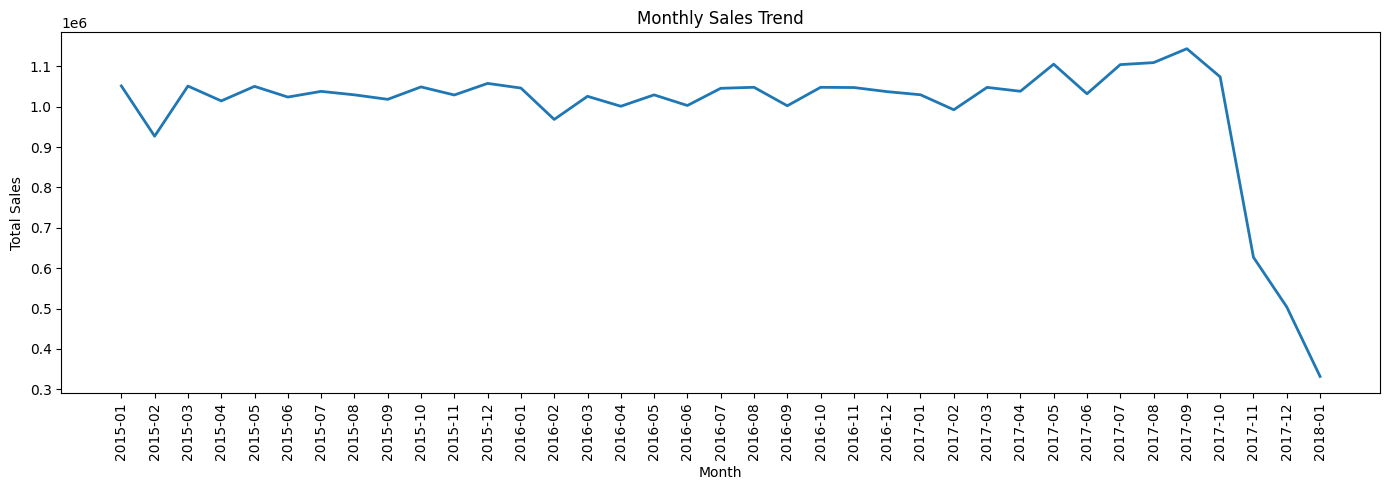

In [ ]:
# ============================================
# PHASE D - EDA
# 1. MONTHLY SALES TREND
# ============================================

monthly_sales = (
    clean_df.groupby(
        clean_df["order date (DateOrders)"].dt.to_period("M")
    )["Sales"]
    .sum()
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    linewidth=2
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

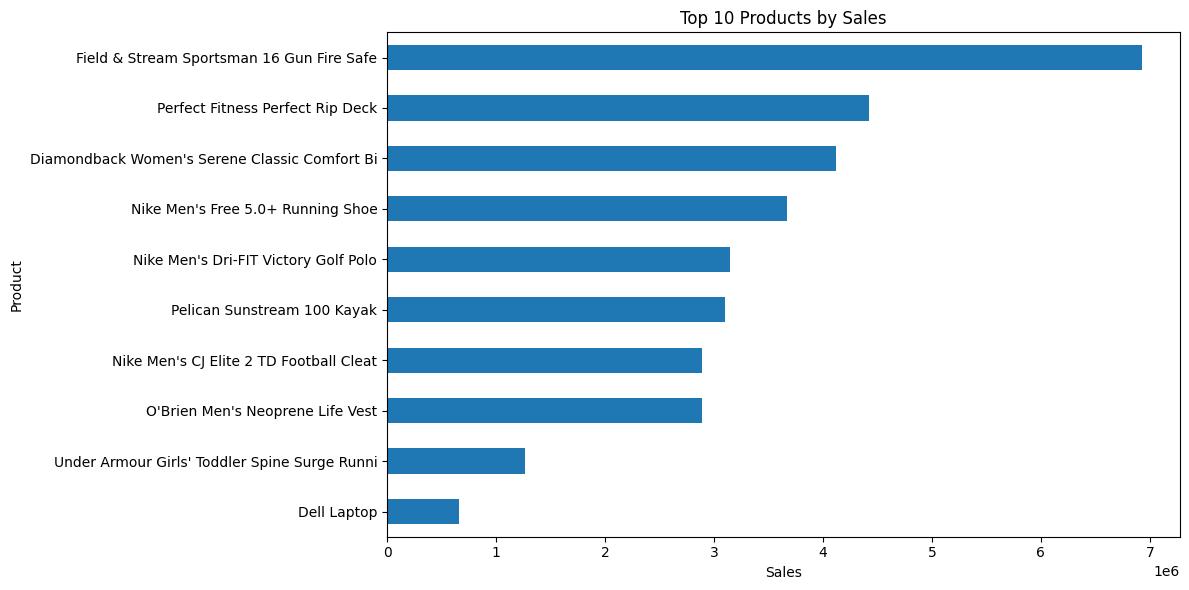

In [ ]:
# ============================================
# 2. TOP PRODUCTS BY SALES
# ============================================

top_products = (
    clean_df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 3. CATEGORY PERFORMANCE
# ============================================

category_analysis = (
    clean_df.groupby("Category Name")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("Order Id", "nunique"),
        Units=("Order Item Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

display(category_analysis.head(15))

,Revenue,Orders,Units
Category Name,,,
Fishing,6.929654e+06,15164,17325
Cleats,4.431943e+06,20386,73734
Camping & Hiking,4.118426e+06,12299,13729
Cardio Equipment,3.694843e+06,11355,37587
Women's Apparel,3.147800e+06,17869,62956
Water Sports,3.113845e+06,13758,15540
Men's Footwear,2.891758e+06,18783,22246
Indoor/Outdoor Games,2.888994e+06,16623,57803
Shop By Sport,1.309522e+06,10136,32726


In [ ]:
# ============================================
# 4. REGIONAL PERFORMANCE
# ============================================

regional_analysis = (
    clean_df.groupby("Order Region")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("Order Id", "nunique"),
        Late_Rate=("Late Delivery", "mean"),
        Avg_Delivery=("Days for shipping (real)", "mean")
    )
    .reset_index()
)

# Convert late-delivery rate to percentage
regional_analysis["Late_Rate"] = (
    regional_analysis["Late_Rate"] * 100
)

# Rename for readability
regional_analysis = regional_analysis.rename(
    columns={"Late_Rate": "Late_Rate (%)"}
)

display(
    regional_analysis
    .sort_values("Revenue", ascending=False)
    .head(15)
)

,Order Region,Revenue,Orders,Late_Rate (%),Avg_Delivery
22,Western Europe,5.894381e+06,10010,55.848611,3.498432
3,Central America,5.665712e+06,9396,54.754596,3.510462
12,South America,2.960881e+06,4979,54.308671,3.505725
10,Northern Europe,2.155831e+06,3716,54.044118,3.502349
17,Southern Europe,2.047919e+06,3543,54.384477,3.435797
11,Oceania,2.016654e+06,4362,54.020497,3.496354
15,Southeast Asia,1.932496e+06,4356,55.529930,3.496698
1,Caribbean,1.651019e+06,2806,53.077663,3.507213
21,West of USA,1.571416e+06,2667,53.959715,3.504942
13,South Asia,1.553681e+06,3335,56.266977,3.502005


In [ ]:
# ============================================
# PHASE D5 - SHIPPING MODE ANALYSIS
# ============================================

shipping_analysis = (
    clean_df.groupby("Shipping Mode")
    .agg(
        Orders=("Order Id", "nunique"),
        Avg_Delivery_Days=("Days for shipping (real)", "mean"),
        Late_Delivery_Rate=("Late Delivery", "mean"),
        Revenue=("Sales", "sum")
    )
    .reset_index()
)

shipping_analysis["Late_Delivery_Rate (%)"] = (
    shipping_analysis["Late_Delivery_Rate"] * 100
)

shipping_analysis = shipping_analysis.drop(
    columns=["Late_Delivery_Rate"]
)

display(
    shipping_analysis.sort_values(
        "Late_Delivery_Rate (%)",
        ascending=False
    )
)

,Shipping Mode,Orders,Avg_Delivery_Days,Revenue,Late_Delivery_Rate (%)
0,First Class,10079,2.000000,5.674370e+06,95.322499
2,Second Class,12778,3.990828,7.145445e+06,76.632781
1,Same Day,3571,0.478279,1.942529e+06,45.743042
3,Standard Class,39324,3.995907,2.202239e+07,38.071683


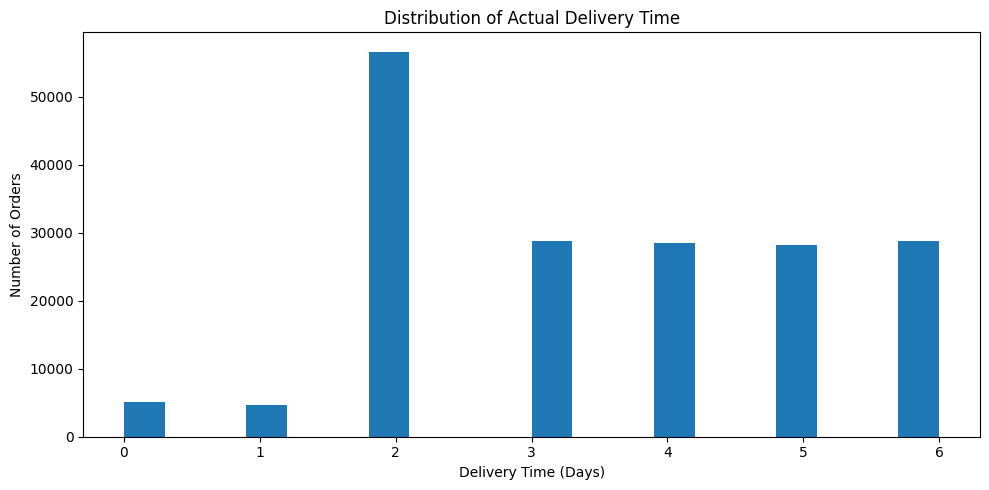

In [ ]:
# ============================================
# PHASE D6 - DELIVERY TIME DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["Days for shipping (real)"].dropna(),
    bins=20
)

plt.title("Distribution of Actual Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE D7 - REGIONAL LATE DELIVERY ANALYSIS
# ============================================

regional_delay = (
    clean_df.groupby("Order Region")
    .agg(
        Orders=("Order Id", "nunique"),
        Late_Orders=("Late Delivery", "sum"),
        Avg_Delivery_Days=("Days for shipping (real)", "mean")
    )
    .reset_index()
)

regional_delay["Late_Delivery_Rate (%)"] = (
    regional_delay["Late_Orders"]
    / regional_delay["Orders"]
) * 100

regional_delay = regional_delay.sort_values(
    "Late_Delivery_Rate (%)",
    ascending=False
)

display(regional_delay.head(15))

,Order Region,Orders,Late_Orders,Avg_Delivery_Days,Late_Delivery_Rate (%)
2,Central Africa,556,972,3.560525,174.820144
5,East Africa,613,1036,3.514579,169.004894
8,Eastern Europe,1292,2182,3.500765,168.885449
18,US Center,1935,3252,3.457618,168.062016
14,South of USA,1345,2256,3.492707,167.732342
4,Central Asia,184,306,3.417722,166.304348
6,East of USA,2323,3849,3.500940,165.690917
9,North Africa,1064,1762,3.480507,165.601504
3,Central America,9396,15518,3.510462,165.155385
20,West Asia,2022,3322,3.486770,164.292779


In [ ]:
# ============================================
# PHASE D8 - CUSTOMER SEGMENT ANALYSIS
# ============================================

segment_analysis = (
    clean_df.groupby("Customer Segment")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("Order Id", "nunique"),
        Units=("Order Item Quantity", "sum"),
        Avg_Order_Value=("Sales", "mean")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

display(segment_analysis)

,Customer Segment,Revenue,Orders,Units,Avg_Order_Value
0,Consumer,1.909579e+07,34119,199234,204.224313
1,Corporate,1.116841e+07,19856,116560,203.843962
2,Home Office,6.520538e+06,11777,68285,202.337802


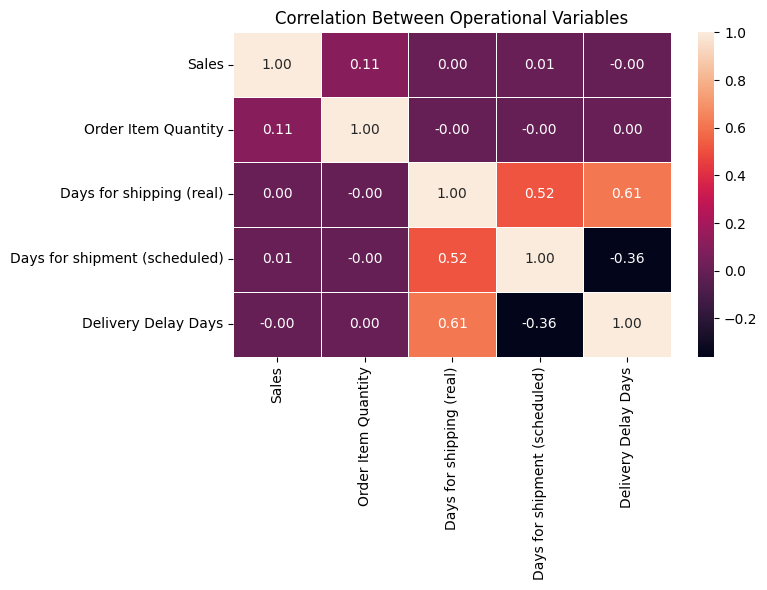

In [ ]:
# ============================================
# PHASE D9 - CORRELATION ANALYSIS
# ============================================

corr_cols = [
    "Sales",
    "Order Item Quantity",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Delay Days"
]

correlation = clean_df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Operational Variables")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE D10 - OUTLIER ANALYSIS
# ============================================

def get_iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper


outlier_results = []

for col in [
    "Sales",
    "Order Item Quantity",
    "Days for shipping (real)",
    "Delivery Delay Days"
]:

    lower, upper = get_iqr_bounds(clean_df[col])

    count = (
        (clean_df[col] < lower) |
        (clean_df[col] > upper)
    ).sum()

    outlier_results.append({
        "Variable": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

outlier_table = pd.DataFrame(outlier_results)

display(outlier_table)

,Variable,Lower Bound,Upper Bound,Outlier Count
0,Sales,-149.97501,569.905025,488
1,Order Item Quantity,-2.00000,6.000000,0
2,Days for shipping (real),-2.50000,9.500000,0
3,Delivery Delay Days,-1.50000,2.500000,35701


In [ ]:
# ============================================
# PHASE E - SUPPLIER FIELD CHECK
# ============================================

supplier_candidates = [
    col for col in clean_df.columns
    if "supplier" in col.lower()
]

print("Supplier-related columns found:")
print(supplier_candidates)

if len(supplier_candidates) == 0:
    print("\nNo reliable supplier identifier is present in the DataCo dataset.")
    print("Supplier scorecard will NOT be fabricated.")

Supplier-related columns found:
[]

No reliable supplier identifier is present in the DataCo dataset.
Supplier scorecard will NOT be fabricated.


In [ ]:
# ============================================
# PHASE F - DEMAND-BASED INVENTORY ANALYTICS
# ============================================

product_demand = (
    clean_df
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        Units_Sold=("Order Item Quantity", "sum"),
        Orders=("Order Id", "nunique"),
        Revenue=("Sales", "sum")
    )
    .reset_index()
)

product_demand["Average_Units_per_Order"] = (
    product_demand["Units_Sold"] /
    product_demand["Orders"]
)

product_demand = product_demand.sort_values(
    "Units_Sold",
    ascending=False
)

display(product_demand.head(20))

,Product Card Id,Product Name,Units_Sold,Orders,Revenue,Average_Units_per_Order
35,365,Perfect Fitness Perfect Rip Deck,73698,20359,4.421143e+06,3.619922
37,502,Nike Men's Dri-FIT Victory Golf Polo,62956,17869,3.147800e+06,3.523197
97,1014,O'Brien Men's Neoprene Life Vest,57803,16623,2.888994e+06,3.477291
15,191,Nike Men's Free 5.0+ Running Shoe,36680,11092,3.667633e+06,3.306888
44,627,Under Armour Girls' Toddler Spine Surge Runni,31735,9825,1.269083e+06,3.230025
36,403,Nike Men's CJ Elite 2 TD Football Cleat,22246,18783,2.891758e+06,1.184369
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,17325,15164,6.929654e+06,1.142509
99,1073,Pelican Sunstream 100 Kayak,15500,13727,3.099845e+06,1.129162
92,957,Diamondback Women's Serene Classic Comfort Bi,13729,12299,4.118426e+06,1.116270
93,977,ENO Atlas Hammock Straps,998,321,2.993002e+04,3.109034


In [ ]:
# ============================================
# PHASE F2 - FAST / MEDIUM / SLOW MOVERS
# ============================================

product_demand["Demand_Band"] = pd.qcut(
    product_demand["Units_Sold"].rank(method="first"),
    q=3,
    labels=["Slow Mover", "Medium Mover", "Fast Mover"]
)

print("Demand band distribution:")
display(product_demand["Demand_Band"].value_counts())

print("\nTop demand-driven products:")
display(
    product_demand[
        [
            "Product Card Id",
            "Product Name",
            "Units_Sold",
            "Orders",
            "Revenue",
            "Demand_Band"
        ]
    ].head(20)
)

Demand band distribution:


,count
Demand_Band,
Fast Mover,40
Slow Mover,39
Medium Mover,39



Top demand-driven products:


,Product Card Id,Product Name,Units_Sold,Orders,Revenue,Demand_Band
35,365,Perfect Fitness Perfect Rip Deck,73698,20359,4.421143e+06,Fast Mover
37,502,Nike Men's Dri-FIT Victory Golf Polo,62956,17869,3.147800e+06,Fast Mover
97,1014,O'Brien Men's Neoprene Life Vest,57803,16623,2.888994e+06,Fast Mover
15,191,Nike Men's Free 5.0+ Running Shoe,36680,11092,3.667633e+06,Fast Mover
44,627,Under Armour Girls' Toddler Spine Surge Runni,31735,9825,1.269083e+06,Fast Mover
36,403,Nike Men's CJ Elite 2 TD Football Cleat,22246,18783,2.891758e+06,Fast Mover
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,17325,15164,6.929654e+06,Fast Mover
99,1073,Pelican Sunstream 100 Kayak,15500,13727,3.099845e+06,Fast Mover
92,957,Diamondback Women's Serene Classic Comfort Bi,13729,12299,4.118426e+06,Fast Mover
93,977,ENO Atlas Hammock Straps,998,321,2.993002e+04,Fast Mover


In [ ]:
# ============================================
# PHASE F3 - DEMAND VARIABILITY
# ============================================

monthly_product_demand = (
    clean_df
    .assign(
        Month=clean_df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby(
        ["Product Card Id", "Product Name", "Month"]
    )["Order Item Quantity"]
    .sum()
    .reset_index(name="Monthly_Units_Sold")
)

demand_variability = (
    monthly_product_demand
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        Average_Monthly_Demand=("Monthly_Units_Sold", "mean"),
        Demand_Std=("Monthly_Units_Sold", "std"),
        Peak_Monthly_Demand=("Monthly_Units_Sold", "max")
    )
    .reset_index()
)

demand_variability["Coefficient_of_Variation"] = (
    demand_variability["Demand_Std"] /
    demand_variability["Average_Monthly_Demand"].replace(0, np.nan)
)

display(
    demand_variability
    .sort_values("Coefficient_of_Variation", ascending=False)
    .head(20)
)

,Product Card Id,Product Name,Average_Monthly_Demand,Demand_Std,Peak_Monthly_Demand,Coefficient_of_Variation
103,1349,Web Camera,296.000000,394.565584,575,1.332992
108,1354,DVDs,161.000000,185.547837,367,1.152471
111,1357,Men's gala suit,104.000000,103.237590,177,0.992669
109,1355,Lawn mower,242.000000,206.475180,388,0.853203
104,1350,Children's heaters,326.000000,277.185858,522,0.850263
6,60,SOLE E25 Elliptical,5.000000,4.242641,8,0.848528
105,1351,Dell Laptop,221.000000,182.433550,350,0.825491
100,1346,Sports Books,202.500000,149.199531,308,0.736788
47,647,Merrell Women's Siren Mid Waterproof Hiking B,11.666667,8.334667,25,0.714400
55,715,TaylorMade Women's RBZ SL Rescue,11.333333,7.991662,25,0.705147


In [ ]:
# ============================================
# PHASE F4 - REPLENISHMENT PRIORITY
# ============================================

inventory_analysis = product_demand.merge(
    demand_variability,
    on=["Product Card Id", "Product Name"],
    how="left"
)

inventory_analysis["Demand_Score"] = (
    inventory_analysis["Units_Sold"]
    .rank(pct=True)
)

inventory_analysis["Variability_Score"] = (
    inventory_analysis["Coefficient_of_Variation"]
    .fillna(0)
    .rank(pct=True)
)

inventory_analysis["Priority_Score"] = (
    0.6 * inventory_analysis["Demand_Score"] +
    0.4 * inventory_analysis["Variability_Score"]
)

inventory_analysis["Replenishment_Priority"] = pd.cut(
    inventory_analysis["Priority_Score"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["Low", "Medium", "High"]
)

display(
    inventory_analysis
    .sort_values("Priority_Score", ascending=False)
    .head(20)
)

,Product Card Id,Product Name,Units_Sold,Orders,Revenue,Average_Units_per_Order,Demand_Band,Average_Monthly_Demand,Demand_Std,Peak_Monthly_Demand,Coefficient_of_Variation,Demand_Score,Variability_Score,Priority_Score,Replenishment_Priority
20,276,Under Armour Women's Ignite Slide,919,306,29398.809778,3.003268,Fast Mover,32.821429,14.676899,65,0.447174,0.830508,0.635593,0.752542,High
17,917,Glove It Women's Mod Oval 3-Zip Carry All Gol,930,294,20450.699747,3.163265,Fast Mover,33.214286,12.982487,60,0.390871,0.860169,0.559322,0.739831,High
45,1362,Fighting video games,838,838,33310.500000,1.000000,Medium Mover,419.000000,270.114790,610,0.644665,0.618644,0.872881,0.720339,High
22,823,Titleist Pro V1x High Numbers Personalized Go,908,305,47206.921463,2.977049,Fast Mover,32.428571,12.787229,51,0.394320,0.813559,0.567797,0.715254,High
57,1349,Web Camera,592,592,267607.685032,1.000000,Medium Mover,296.000000,394.565584,575,1.332992,0.516949,1.000000,0.710169,High
16,926,Glove It Imperial Golf Towel,930,302,14870.699789,3.079470,Fast Mover,33.214286,12.254575,54,0.368955,0.860169,0.483051,0.709322,High
55,1350,Children's heaters,652,652,232829.203977,1.000000,Medium Mover,326.000000,277.185858,522,0.850263,0.533898,0.966102,0.706780,High
14,804,Glove It Women's Imperial Golf Glove,941,303,18810.589794,3.105611,Fast Mover,33.607143,11.985606,53,0.356639,0.881356,0.432203,0.701695,High
19,835,Bridgestone e6 Straight Distance NFL Carolina,928,308,29686.719786,3.012987,Fast Mover,33.142857,12.146374,58,0.366485,0.843220,0.474576,0.695763,High
23,564,Nike Men's Deutschland Weltmeister Winners Bl,907,297,27210.000000,3.053872,Fast Mover,32.392857,12.467259,72,0.384877,0.800847,0.533898,0.694068,High


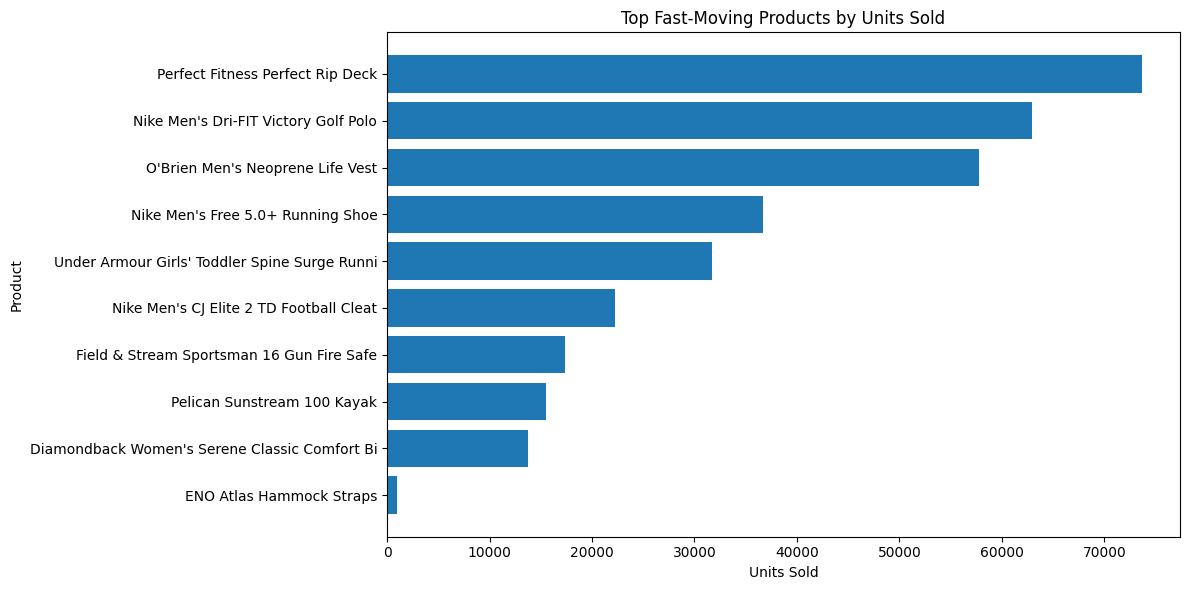

In [ ]:
# ============================================
# PHASE F5 - FAST MOVERS
# ============================================

fast_movers = (
    product_demand[
        product_demand["Demand_Band"] == "Fast Mover"
    ]
    .sort_values("Units_Sold", ascending=False)
    .head(10)
    .sort_values("Units_Sold")
)

plt.figure(figsize=(12, 6))

plt.barh(
    fast_movers["Product Name"],
    fast_movers["Units_Sold"]
)

plt.title("Top Fast-Moving Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE G1 - DESCRIPTIVE STATISTICS
# ============================================

stats_cols = [
    "Sales",
    "Order Item Quantity",
    "Shipping Cost" if "Shipping Cost" in clean_df.columns
        else "Shipping cost",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

stats_cols = [
    col for col in stats_cols
    if col in clean_df.columns
]

display(
    clean_df[stats_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99,119.980003,199.919998,299.950012,1999.98999
Order Item Quantity,180519.0,2.127638,1.453451,1.00,1.000000,1.000000,3.000000,5.00000
Days for shipping (real),180519.0,3.497654,1.623722,0.00,2.000000,3.000000,5.000000,6.00000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00,2.000000,4.000000,4.000000,4.00000


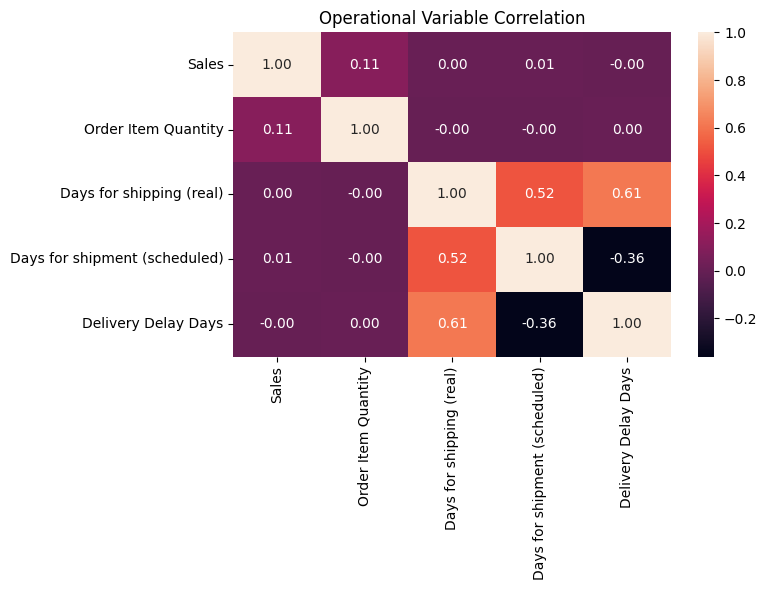

In [ ]:
# ============================================
# PHASE G2 - CORRELATION ANALYSIS
# ============================================

corr_cols = [
    "Sales",
    "Order Item Quantity",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Delivery Delay Days"
]

correlation = clean_df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Operational Variable Correlation")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE G3 - OUTLIER ANALYSIS
# ============================================

outlier_columns = [
    "Sales",
    "Order Item Quantity",
    "Days for shipping (real)",
    "Delivery Delay Days"
]

outlier_results = []

for col in outlier_columns:

    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = (
        (clean_df[col] < lower) |
        (clean_df[col] > upper)
    ).sum()

    outlier_results.append({
        "Variable": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Variable,Lower Bound,Upper Bound,Outlier Count
0,Sales,-149.97501,569.905025,488
1,Order Item Quantity,-2.00000,6.000000,0
2,Days for shipping (real),-2.50000,9.500000,0
3,Delivery Delay Days,-1.50000,2.500000,35701


In [ ]:
# ============================================
# PHASE G4 - HYPOTHESIS TEST
# ============================================

from scipy import stats

shipping_groups = [
    group["Days for shipping (real)"].dropna()
    for _, group in clean_df.groupby("Shipping Mode")
]

anova_result = stats.f_oneway(*shipping_groups)

print("H0: Mean delivery time is the same across shipping modes.")
print("H1: At least one shipping mode has a different mean delivery time.")
print()
print("F-statistic:", round(anova_result.statistic, 4))
print("p-value:", round(anova_result.pvalue, 6))

if anova_result.pvalue < 0.05:
    print("\nConclusion: Reject H0.")
    print("Shipping mode has a statistically significant relationship with delivery time.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("No statistically significant difference was detected.")

H0: Mean delivery time is the same across shipping modes.
H1: At least one shipping mode has a different mean delivery time.

F-statistic: 38762.4138
p-value: 0.0

Conclusion: Reject H0.
Shipping mode has a statistically significant relationship with delivery time.


In [ ]:
# ============================================
# PHASE G5 - STATISTICAL SUMMARY
# ============================================

print("PHASE G - STATISTICS COMPLETED ✅")
print("=" * 60)
print("✓ Descriptive statistics")
print("✓ Correlation analysis")
print("✓ IQR outlier analysis")
print("✓ ANOVA hypothesis test")
print()
print("Statistical analysis is complete.")

PHASE G - STATISTICS COMPLETED ✅
✓ Descriptive statistics
✓ Correlation analysis
✓ IQR outlier analysis
✓ ANOVA hypothesis test

Statistical analysis is complete.


In [ ]:
# ============================================
# PHASE H1 - MONTHLY DEMAND
# ============================================

monthly_demand = (
    clean_df
    .assign(
        Month=clean_df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")["Order Item Quantity"]
    .sum()
)

monthly_demand.index = monthly_demand.index.to_timestamp()

print("Number of monthly periods:", len(monthly_demand))
display(monthly_demand.head(12))

Number of monthly periods: 37


,Order Item Quantity
Month,
2015-01-01,11854
2015-02-01,10438
2015-03-01,12062
2015-04-01,11287
2015-05-01,11902
2015-06-01,11203
2015-07-01,11800
2015-08-01,11612
2015-09-01,11366


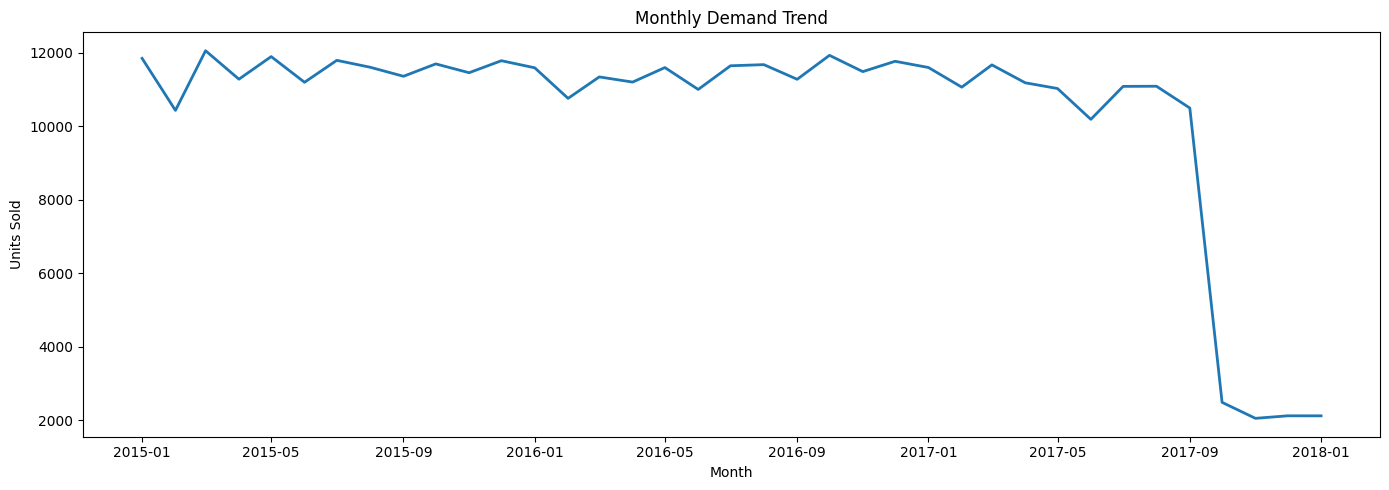

In [ ]:
# ============================================
# PHASE H2 - DEMAND TREND
# ============================================

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    linewidth=2
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE H3 - TIME-AWARE SPLIT
# ============================================

split_index = int(len(monthly_demand) * 0.80)

train = monthly_demand.iloc[:split_index]
test = monthly_demand.iloc[split_index:]

print("Training periods:", len(train))
print("Testing periods:", len(test))
print("Training end:", train.index.max())
print("Testing start:", test.index.min())

Training periods: 29
Testing periods: 8
Training end: 2017-05-01 00:00:00
Testing start: 2017-06-01 00:00:00


In [ ]:
# ============================================
# PHASE H4 - BASELINE + FORECAST
# ============================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive baseline
naive_forecast = np.repeat(
    train.iloc[-1],
    len(test)
)

naive_mae = mean_absolute_error(
    test,
    naive_forecast
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test,
        naive_forecast
    )
)

# Holt-Winters / Exponential Smoothing
forecast_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

fitted_model = forecast_model.fit()

forecast = fitted_model.forecast(
    len(test)
)

forecast_mae = mean_absolute_error(
    test,
    forecast
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

forecast_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Holt-Winters"
    ],
    "MAE": [
        naive_mae,
        forecast_mae
    ],
    "RMSE": [
        naive_rmse,
        forecast_rmse
    ]
})

display(forecast_results)

,Model,MAE,RMSE
0,Naive Baseline,4603.75000,6258.382419
1,Holt-Winters,4925.56636,6514.450687


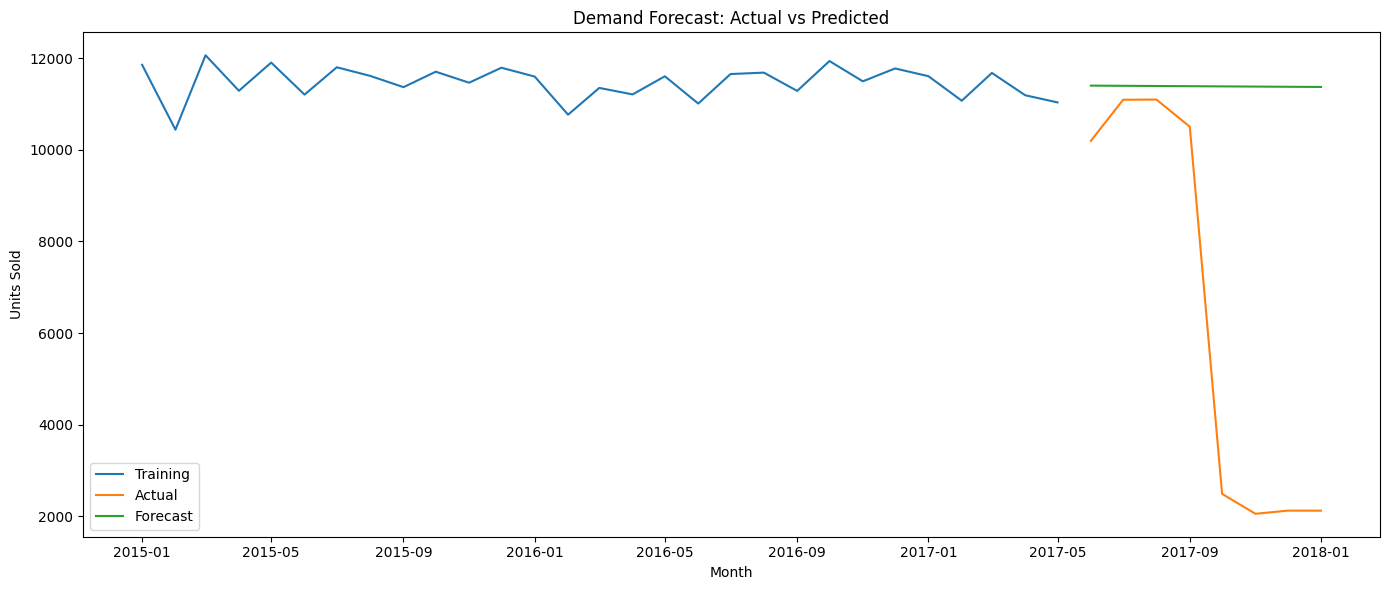

In [ ]:
# ============================================
# PHASE H5 - ACTUAL VS FORECAST
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train.values,
    label="Training"
)

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    forecast.values,
    label="Forecast"
)

plt.title("Demand Forecast: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PHASE H6 - FORECAST INTERPRETATION
# ============================================

best_model = forecast_results.sort_values("RMSE").iloc[0]

print("FORECASTING SUMMARY")
print("=" * 60)
print("Best model by RMSE:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 2))
print("RMSE:", round(best_model["RMSE"], 2))

print("""
Business Use:
• Forecast future demand for planning.
• Prioritize capacity and replenishment for high-demand products.
• Use forecast trends to support inventory planning.
""")

FORECASTING SUMMARY
Best model by RMSE: Naive Baseline
MAE: 4603.75
RMSE: 6258.38

Business Use:
• Forecast future demand for planning.
• Prioritize capacity and replenishment for high-demand products.
• Use forecast trends to support inventory planning.



In [ ]:
# ============================================
# PHASE I1 - LATE DELIVERY PREDICTION
# LEAKAGE-SAFE FEATURE SET
# ============================================

ml_df = clean_df.copy()

# Features available before / around order processing
categorical_features = [
    "Shipping Mode",
    "Market",
    "Order Region",
    "Category Name",
    "Customer Segment"
]

numeric_features = [
    "Order Item Quantity",
    "Sales"
]

target = "Late Delivery"

# Check that required columns exist
required_cols = categorical_features + numeric_features + [target]

missing_cols = [
    col for col in required_cols
    if col not in ml_df.columns
]

print("Missing required columns:", missing_cols)

if missing_cols:
    raise ValueError(
        f"Missing columns: {missing_cols}"
    )

model_df = ml_df[
    required_cols
].dropna()

# One-hot encode categorical variables
X = pd.get_dummies(
    model_df[categorical_features + numeric_features],
    drop_first=True
)

y = model_df[target].astype(int)

print("MODEL DATA")
print("=" * 60)
print("Rows:", len(model_df))
print("Features:", X.shape[1])

print("\nTarget distribution:")
display(
    y.value_counts()
    .rename(index={0: "On Time", 1: "Late"})
    .to_frame("Count")
)

print("\nTarget percentage:")
display(
    (y.value_counts(normalize=True) * 100)
    .rename(index={0: "On Time", 1: "Late"})
    .round(2)
    .to_frame("Percentage")
)

Missing required columns: []
MODEL DATA
Rows: 180519
Features: 82

Target distribution:


,Count
Late Delivery,
Late,98977
On Time,81542



Target percentage:


,Percentage
Late Delivery,
Late,54.83
On Time,45.17


In [ ]:
# ============================================
# PHASE I2 - TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training target rate:", round(y_train.mean() * 100, 2), "%")
print("Testing target rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 144415
Testing rows: 36104
Training target rate: 54.83 %
Testing target rate: 54.83 %


In [ ]:
# ============================================
# PHASE I3 - MODEL COMPARISON
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities
        )
    })

    trained_models[name] = model

model_comparison = (
    pd.DataFrame(results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.6970,0.8459,0.5470,0.6644,0.7331
1,Random Forest,0.6832,0.7964,0.5672,0.6626,0.7187
2,Logistic Regression,0.6967,0.8502,0.5425,0.6624,0.7292


In [ ]:
# ============================================
# PHASE I4 - BEST MODEL
# ============================================

best_model_name = model_comparison.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]

print("Best model:", best_model_name)

display(
    model_comparison[
        model_comparison["Model"] == best_model_name
    ].round(4)
)

Best model: Gradient Boosting


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.697,0.8459,0.547,0.6644,0.7331


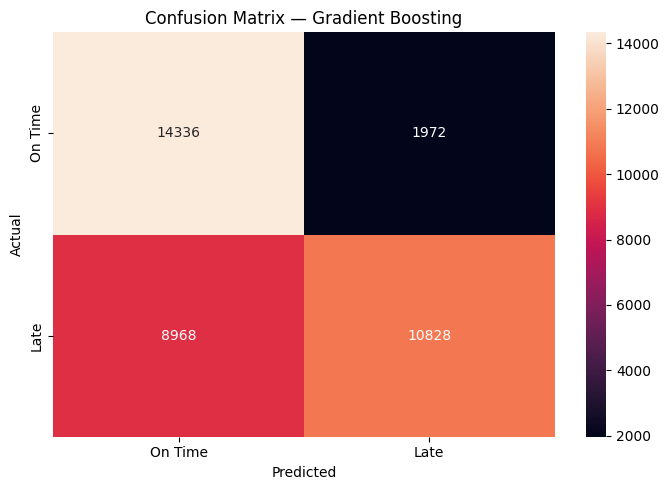


Classification Report:
              precision    recall  f1-score   support

     On Time       0.62      0.88      0.72     16308
        Late       0.85      0.55      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



In [ ]:
# ============================================
# PHASE I5 - CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["On Time", "Late"],
    yticklabels=["On Time", "Late"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["On Time", "Late"],
        zero_division=0
    )
)

,Feature,Importance
4,Shipping Mode_Standard Class,0.794267
2,Shipping Mode_Same Day,0.136615
3,Shipping Mode_Second Class,0.059663
1,Sales,0.001107
25,Order Region_Southern Europe,0.000659
80,Customer Segment_Corporate,0.000557
12,Order Region_Central Asia,0.000412
9,Order Region_Caribbean,0.000341
10,Order Region_Central Africa,0.000325
0,Order Item Quantity,0.000279


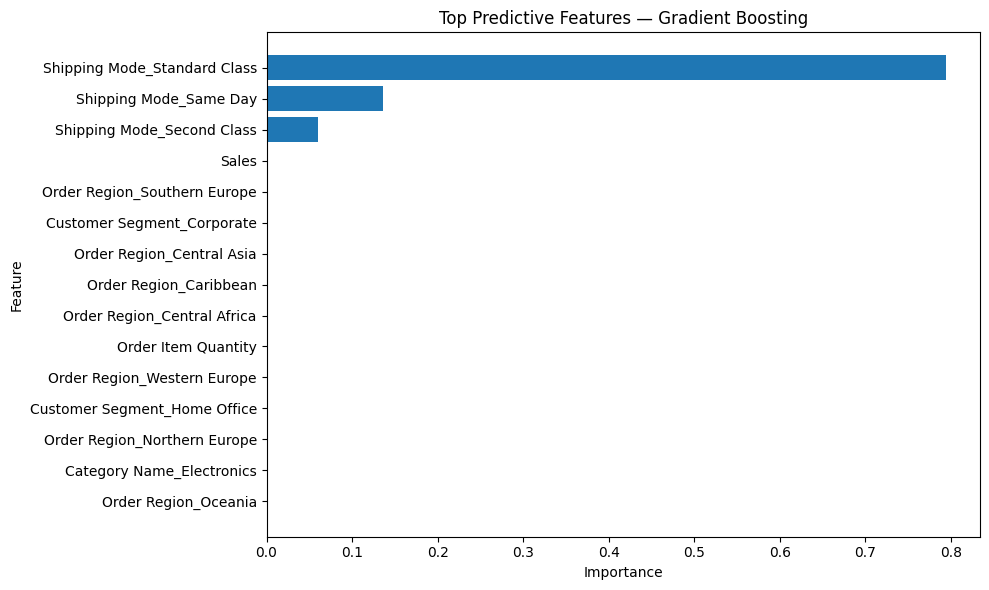

In [ ]:
# ============================================
# PHASE I6 - FEATURE IMPORTANCE
# ============================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = (
        importance
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    display(importance)

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance["Feature"][::-1],
        importance["Importance"][::-1]
    )

    plt.title(f"Top Predictive Features — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print(
        "Feature importance visualization is not available "
        "for the selected model."
    )

In [ ]:
# ============================================
# EXPORT POWER BI DATASETS
# ============================================

# 1. KPI table
kpi_table.to_csv("powerbi_kpis.csv", index=False)

# 2. Category analysis
category_analysis.to_csv("powerbi_category_analysis.csv", index=False)

# 3. Regional analysis
regional_analysis.to_csv("powerbi_regional_analysis.csv", index=False)

# 4. Shipping analysis
shipping_analysis.to_csv("powerbi_shipping_analysis.csv", index=False)

# 5. Product / demand analysis
inventory_analysis.to_csv("powerbi_inventory_demand.csv", index=False)

# 6. Forecast results
forecast_output = pd.DataFrame({
    "Date": test.index,
    "Actual_Demand": test.values,
    "Forecast_Demand": forecast.values
})

forecast_output.to_csv(
    "powerbi_forecast.csv",
    index=False
)

# 7. ML model comparison
model_comparison.to_csv(
    "powerbi_ml_model_comparison.csv",
    index=False
)

print("Power BI datasets exported successfully ✅")

import os

files_created = [
    f for f in os.listdir()
    if f.startswith("powerbi_")
]

print("\nFiles ready for Power BI:")
for f in files_created:
    print("✓", f)

Power BI datasets exported successfully ✅

Files ready for Power BI:
✓ powerbi_inventory_demand.csv
✓ powerbi_ml_model_comparison.csv
✓ powerbi_category_analysis.csv
✓ powerbi_shipping_analysis.csv
✓ powerbi_forecast.csv
✓ powerbi_kpis.csv
✓ powerbi_regional_analysis.csv


In [ ]:
# ============================================
# DOWNLOAD POWER BI DATA
# ============================================

import zipfile
from google.colab import files
import os

powerbi_files = [
    f for f in os.listdir()
    if f.startswith("powerbi_") and f.endswith(".csv")
]

with zipfile.ZipFile(
    "SupplyChain_PowerBI_Data.zip",
    "w"
) as zipf:
    for file in powerbi_files:
        zipf.write(file)

print("Created ZIP with:")
for file in powerbi_files:
    print("✓", file)

files.download("SupplyChain_PowerBI_Data.zip")

Created ZIP with:
✓ powerbi_inventory_demand.csv
✓ powerbi_ml_model_comparison.csv
✓ powerbi_category_analysis.csv
✓ powerbi_shipping_analysis.csv
✓ powerbi_forecast.csv
✓ powerbi_kpis.csv
✓ powerbi_regional_analysis.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>